In [1]:
!date

Wed Sep 16 19:23:31 PDT 2026


In [2]:
import sys
import subprocess
import numpy as np
import pandas as pd

projdir = '/u/project/cluo/terencew/claude/project_ideas/asm_lr_hprc2'
sys.path.insert(0, f'{projdir}/scripts/harmonize_hg38/pilot')
import chainmap

bedtools = '/u/home/t/terencew/bin/bedtools'
pmd_pilot_dir = f'{projdir}/results/qc/data/pmd_pilot_chr20'

### NOTE: the full 202-donor x 2-hap PMD array (jobs 14771403 -> 14771405) was still running
### (~35/404 A01a tasks active, A01c not started) when this notebook was built, so NA19338's
### chr20 methcounts/PMD calls were regenerated directly here (same script, same parameters
### already validated earlier this session) rather than waiting -- written to
### results/qc/data/pmd_pilot_chr20/, NOT to data/pmds/NA19338/, to avoid the production array
### later seeing a chr20-only file at that path and skip-if-exists-ing past a real full-genome
### run for this donor. Re-run this notebook against data/pmds/ once the array actually finishes
### for genome-wide, full-cohort numbers -- everything below is a chr20-only pilot.

In [3]:
### lift NA19338's native-coordinate PMD calls to hg38 via the existing chain files
cm1 = chainmap.ChainMap(f'{projdir}/data/chains/NA19338_hap1_vs_GRCh38.chain.gz')
cm2 = chainmap.ChainMap(f'{projdir}/data/chains/NA19338_hap2_vs_GRCh38.chain.gz')

def lift_pmd_bed(path, cm, bare_contig):
    out = []
    with open(path) as fh:
        for line in fh:
            f = line.split('\t')
            start, end = int(f[1]), int(f[2])
            r0 = cm.t_to_q(bare_contig, start)
            r1 = cm.t_to_q(bare_contig, end - 1)
            if r0 is None or r1 is None or r0[0] != r1[0]:
                continue
            q0, q1 = sorted([r0[1], r1[1]])
            out.append((r0[0], q0, q1 + 1))
    return out

pmd1 = lift_pmd_bed(f'{pmd_pilot_dir}/NA19338_hap1.pmd.bed', cm1, 'CM087770.1')
pmd2 = lift_pmd_bed(f'{pmd_pilot_dir}/NA19338_hap2.pmd.bed', cm2, 'CM087786.1')
print(f'hap1: {len(pmd1)}/87 PMDs lifted to hg38')
print(f'hap2: {len(pmd2)}/79 PMDs lifted to hg38')

hap1: 84/87 PMDs lifted to hg38
hap2: 72/79 PMDs lifted to hg38


In [4]:
with open(f'{pmd_pilot_dir}/NA19338_hap1.pmd.hg38.bed', 'w') as out:
    for chrom, s, e in sorted(pmd1):
        out.write(f'{chrom}\t{s}\t{e}\n')
with open(f'{pmd_pilot_dir}/NA19338_hap2.pmd.hg38.bed', 'w') as out:
    for chrom, s, e in sorted(pmd2):
        out.write(f'{chrom}\t{s}\t{e}\n')

subprocess.run(f"cat {pmd_pilot_dir}/NA19338_hap1.pmd.hg38.bed {pmd_pilot_dir}/NA19338_hap2.pmd.hg38.bed "
               f"| sort -k1,1 -k2,2n > /tmp/na19338_pmd_both.bed", shell=True, check=True)
subprocess.run(f"{bedtools} merge -i /tmp/na19338_pmd_both.bed > {pmd_pilot_dir}/NA19338_pmd_merged_hg38.bed",
               shell=True, check=True)
pmd_merged = pd.read_csv(f'{pmd_pilot_dir}/NA19338_pmd_merged_hg38.bed', sep='\t', header=None,
                          names=['chrom','start','end'])
pmd_merged['size'] = pmd_merged['end'] - pmd_merged['start']
print(f'{len(pmd_merged)} merged (hap1 U hap2) PMD regions on hg38 chr20')
print(f"total: {pmd_merged['size'].sum()/1e6:.1f} Mb")

77 merged (hap1 U hap2) PMD regions on hg38 chr20
total: 38.9 Mb


In [5]:
pmd_merged['size'].describe()

count    7.700000e+01
mean     5.051206e+05
std      5.749507e+05
min      9.702000e+04
25%      1.424950e+05
50%      2.331630e+05
75%      6.067650e+05
max      2.705187e+06
Name: size, dtype: float64

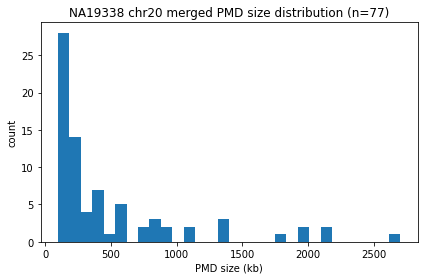

In [6]:
### size distribution
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(6,4))
ax.hist(pmd_merged['size']/1e3, bins=30)
ax.set_xlabel('PMD size (kb)')
ax.set_ylabel('count')
ax.set_title('NA19338 chr20 merged PMD size distribution (n={})'.format(len(pmd_merged)))
plt.tight_layout()
import os
os.makedirs(f'{projdir}/results/qc/figures', exist_ok=True)
fig.savefig(f'{projdir}/results/qc/figures/qc10_na19338_pmd_size_dist.png', dpi=150, bbox_inches='tight')

In [7]:
### genomic coverage on chr20
chromsizes_path = '/u/project/cluo/terencew/reference/hg38_igvf/GRCh38.autosomal.chromsizes'
with open(chromsizes_path) as fh:
    chr20_size = int([l.split('\t')[1] for l in fh if l.startswith('chr20\t')][0])
pct_covered = 100 * pmd_merged['size'].sum() / chr20_size
print(f'chr20 size: {chr20_size:,} bp')
print(f'NA19338 merged PMD coverage of chr20: {pct_covered:.1f}%')

chr20 size: 64,444,167 bp
NA19338 merged PMD coverage of chr20: 60.4%


In [8]:
### fibroblast PMD overlap (reference/igvf_pgp -- the user's own merged fibroblast PMD set)
subprocess.run(f"zcat {projdir}/reference/igvf_pgp/start_merged.filt_mcg.sorted.bed.gz "
               f"| awk '$1==\"chr20\"' > /tmp/fibroblast_chr20.bed", shell=True, check=True)
subprocess.run(f"{bedtools} intersect -a {pmd_pilot_dir}/NA19338_pmd_merged_hg38.bed "
               f"-b /tmp/fibroblast_chr20.bed > /tmp/overlap.bed", shell=True, check=True)

na_bases = pmd_merged['size'].sum()
fib = pd.read_csv('/tmp/fibroblast_chr20.bed', sep='\t', header=None, names=['chrom','start','end'])
fib_bases = (fib['end'] - fib['start']).sum()
overlap = pd.read_csv('/tmp/overlap.bed', sep='\t', header=None, names=['chrom','start','end'])
overlap_bases = (overlap['end'] - overlap['start']).sum() if len(overlap) else 0

print(f'NA19338 (LCL) PMD bases on chr20: {na_bases:,}')
print(f'Fibroblast PMD bases on chr20: {fib_bases:,}')
print(f'Overlap bases: {overlap_bases:,}')
print(f'% of NA19338 PMD covered by fibroblast PMD: {100*overlap_bases/na_bases:.1f}%')
print(f'% of fibroblast PMD covered by NA19338 PMD: {100*overlap_bases/fib_bases:.1f}%')

NA19338 (LCL) PMD bases on chr20: 38,894,286
Fibroblast PMD bases on chr20: 18,651,996
Overlap bases: 16,809,952
% of NA19338 PMD covered by fibroblast PMD: 43.2%
% of fibroblast PMD covered by NA19338 PMD: 90.1%


In [9]:
### gene enrichment: gene density inside vs outside NA19338's PMD regions (chr20)
genes_path = '/u/project/cluo/terencew/reference/hg38_igvf/bed/genes/gencode.v43.autosome.dedup.names.bed.gz'
subprocess.run(f"zcat {genes_path} | awk '$1==\"chr20\"' > /tmp/genes_chr20.bed", shell=True, check=True)
subprocess.run(f"sort -k1,1 -k2,2n {pmd_pilot_dir}/NA19338_pmd_merged_hg38.bed > /tmp/na19338_pmd_sorted.bed",
               shell=True, check=True)
with open('/tmp/chr20.genome', 'w') as f:
    f.write(f'chr20\t{chr20_size}\n')
subprocess.run(f"{bedtools} complement -i /tmp/na19338_pmd_sorted.bed -g /tmp/chr20.genome "
               f"> /tmp/na19338_nonpmd.bed", shell=True, check=True)

def bp_overlap(a, b):
    r = subprocess.run(f"{bedtools} intersect -a {a} -b {b}", shell=True, capture_output=True, text=True)
    if not r.stdout.strip():
        return 0
    df = pd.read_csv(pd.io.common.StringIO(r.stdout), sep='\t', header=None)
    return (df[2] - df[1]).sum()

gene_in_pmd = bp_overlap('/tmp/genes_chr20.bed', '/tmp/na19338_pmd_sorted.bed')
gene_in_nonpmd = bp_overlap('/tmp/genes_chr20.bed', '/tmp/na19338_nonpmd.bed')
pmd_bases = na_bases
nonpmd_bases = chr20_size - na_bases

gene_density_pmd = gene_in_pmd / pmd_bases
gene_density_nonpmd = gene_in_nonpmd / nonpmd_bases
print(f'gene bp / Mb inside PMD: {gene_density_pmd*1e6:.0f}')
print(f'gene bp / Mb outside PMD: {gene_density_nonpmd*1e6:.0f}')
print(f'depletion ratio (in/out): {gene_density_pmd/gene_density_nonpmd:.2f}')

gene bp / Mb inside PMD: 551810
gene bp / Mb outside PMD: 747122
depletion ratio (in/out): 0.74


In [10]:
### residual methylation in OTHER donors, inside vs outside NA19338's PMD regions
### uses P03's production per-sample-chrom hg38 CpG matrix (het-filtered, k>=1) for chr20 --
### the only already-hg38-anchored per-donor methylation source available at notebook time
meth_full = pd.read_csv(f'{projdir}/results/qc/data/global_methylation_covariates_full_cohort.tsv', sep='\t')
per_donor_global = meth_full.groupby('sample_id')['frac_meth'].mean()

from pathlib import Path
avail = sorted(f.stem.split('_chr20_')[0] for f in Path(f'{projdir}/results/all_donors/per_sample_chrom').glob('*_chr20_cpg_matrix.tsv.gz'))
avail = [s for s in avail if s in per_donor_global.index]
print(f'{len(avail)} donors have both global-meth data and chr20 P03 output')

110 donors have both global-meth data and chr20 P03 output


In [11]:
### pick 10 donors spanning the available global-methylation range
ranked = per_donor_global.loc[avail].sort_values()
test_donors = list(ranked.iloc[np.linspace(0, len(ranked)-1, 10).astype(int)].index)
print(test_donors)

['HG00290', 'HG00329', 'HG01784', 'HG00408', 'HG02135', 'HG00126', 'HG01978', 'HG00423', 'HG02300', 'HG02129']


In [12]:
starts = pmd_merged['start'].values
ends = pmd_merged['end'].values

def in_pmd(pos):
    idx = np.searchsorted(starts, pos, side='right') - 1
    idx = np.clip(idx, 0, len(starts) - 1)
    return (pos >= starts[idx]) & (pos < ends[idx])

rows = []
for d in test_donors:
    dcpg = pd.read_csv(f'{projdir}/results/all_donors/per_sample_chrom/{d}_chr20_cpg_matrix.tsv.gz', sep='\t')
    dcpg = dcpg.sort_values('hg38_pos')
    mask = in_pmd(dcpg['hg38_pos'].values)
    inside, outside = dcpg[mask], dcpg[~mask]
    frac_in = inside['n_meth'].sum() / (inside['n_meth'].sum() + inside['n_unmeth'].sum())
    frac_out = outside['n_meth'].sum() / (outside['n_meth'].sum() + outside['n_unmeth'].sum())
    rows.append((d, per_donor_global[d], frac_in, frac_out, frac_out - frac_in))

residual = pd.DataFrame(rows, columns=['donor','donor_global_meth','meth_inside_NA19338_pmd',
                                        'meth_outside_NA19338_pmd','diff_out_minus_in'])
residual

,donor,donor_global_meth,meth_inside_NA19338_pmd,meth_outside_NA19338_pmd,diff_out_minus_in
0,HG00290,0.557625,0.442017,0.679681,0.237665
1,HG00329,0.617669,0.527804,0.691301,0.163498
2,HG01784,0.631655,0.553537,0.704369,0.150832
3,HG00408,0.643178,0.562853,0.716161,0.153308
4,HG02135,0.654107,0.582255,0.711128,0.128873
5,HG00126,0.660217,0.596520,0.711833,0.115312
6,HG01978,0.667623,0.601554,0.708969,0.107416
7,HG00423,0.675184,0.611805,0.723123,0.111318
8,HG02300,0.687964,0.627663,0.727097,0.099434
9,HG02129,0.722388,0.674651,0.737361,0.062710


In [13]:
residual.to_csv(f'{projdir}/results/qc/data/pmd_pilot_chr20/residual_methylation_other_donors.tsv',
                sep='\t', index=False)

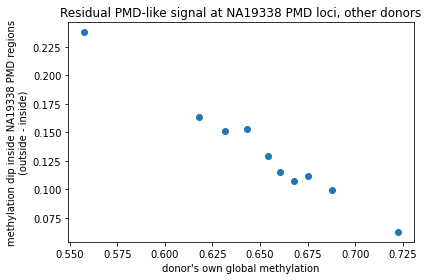

In [14]:
### plot: is the residual dip graded with donor's own global methylation?
fig, ax = plt.subplots(figsize=(6,4))
ax.scatter(residual['donor_global_meth'], residual['diff_out_minus_in'])
ax.set_xlabel("donor's own global methylation")
ax.set_ylabel('methylation dip inside NA19338 PMD regions\n(outside - inside)')
ax.set_title('Residual PMD-like signal at NA19338 PMD loci, other donors')
plt.tight_layout()
fig.savefig(f'{projdir}/results/qc/figures/qc10_residual_methylation_gradient.png', dpi=150, bbox_inches='tight')

In [15]:
!date

Wed Sep 16 19:24:32 PDT 2026
